## ⚙️ **Libraries Import**

In [88]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
logs_dir = "tensorboard"

%load_ext tensorboard

# train_test function
from sklearn.model_selection import train_test_split

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
PyTorch version: 2.6.0+cu124
Device: cuda


## 🔎 **Exploration and Data Analysis**

In [89]:
# Load the dataset from a CSV file
dataset = pd.read_csv('..\\dataset\\Pirate\\pirate_pain_train.csv')
labels = pd.read_csv('..\\dataset\\Pirate\\pirate_pain_train_labels.csv')

# Print the shape of the dataset

print(f"Dataset shape: {dataset.shape}")

# Display the first few rows of the dataset
dataset.head()

Dataset shape: (105760, 40)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5


In [90]:
# Display a concise summary of the DataFrame
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 40 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  int64  
 1   time           105760 non-null  int64  
 2   pain_survey_1  105760 non-null  int64  
 3   pain_survey_2  105760 non-null  int64  
 4   pain_survey_3  105760 non-null  int64  
 5   pain_survey_4  105760 non-null  int64  
 6   n_legs         105760 non-null  object 
 7   n_hands        105760 non-null  object 
 8   n_eyes         105760 non-null  object 
 9   joint_00       105760 non-null  float64
 10  joint_01       105760 non-null  float64
 11  joint_02       105760 non-null  float64
 12  joint_03       105760 non-null  float64
 13  joint_04       105760 non-null  float64
 14  joint_05       105760 non-null  float64
 15  joint_06       105760 non-null  float64
 16  joint_07       105760 non-null  float64
 17  joint_08       105760 non-nul

## 🔄 **Data Preprocessing**

In [91]:
# drop sample_index and joint_30 (zero variance) and add binary encoding of n_limbs features
m = {"two": 2, "one": 1, "zero": 0}
print(dataset["n_legs"].unique())
print(dataset["n_eyes"].unique())
print(dataset["n_hands"].unique())

dataset_bin = pd.DataFrame(dataset.drop(["sample_index", "joint_30"], axis=1))
dataset_bin[["n_legs", "n_hands", "n_eyes"]] = dataset[["n_legs", "n_hands", "n_eyes"]].map(lambda x: 1 if x == "two" else 0)
dataset_bin.head()

['two' 'one+peg_leg']
['two' 'one+eye_patch']
['two' 'one+hook_hand']


,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,joint_01,...,joint_20,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29
0,0,2,0,2,1,1,1,1,1.094705,0.985281,...,6.140248e-07,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815
1,1,2,2,2,2,1,1,1,1.135183,1.021175,...,1.931978e-06,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716
2,2,2,0,2,2,1,1,1,1.080745,0.962842,...,5.730838e-07,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105
3,3,2,2,2,2,1,1,1,0.938017,1.081592,...,3.677486e-05,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648
4,4,2,2,2,2,1,1,1,1.090185,1.032145,...,2.037939e-05,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328


In [92]:
# N: samples, T: time, C: channels
T = 160
N = int(dataset_bin.to_numpy().shape[0] / T)
C = dataset_bin.to_numpy().shape[1]

print(N, T, C)

661 160 38


In [93]:
# HEREGOTO
# reshape dataset
dataset_shaped = dataset_bin.to_numpy().reshape(N, T, C).transpose(0, 2, 1)     # X

sample_shaped = pd.DataFrame(dataset_shaped[0])
sample_shaped.head()

,0,1,2,3,4,5,6,7,8,9,...,150,151,152,153,154,155,156,157,158,159
0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,150.0,151.0,152.0,153.0,154.0,155.0,156.0,157.0,158.0,159.0
1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,...,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
2,0.0,2.0,0.0,2.0,2.0,0.0,1.0,2.0,2.0,2.0,...,2.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0
3,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,...,2.0,2.0,0.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0
4,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,2.0,...,0.0,2.0,2.0,2.0,2.0,1.0,2.0,0.0,2.0,2.0


In [94]:
# standardize by channel
min_val = []
max_val = []

dataset_norm= np.array(dataset_shaped)

for c in range(8, C):
    vals = []
    for n in range(N):
        vals.extend(dataset_shaped[n][c])
    min_val.append(np.min(vals))
    max_val.append(np.max(vals))

for n in range(N):
    for c in range(8, C):
        dataset_norm[n][c] = (dataset_norm[n][c] - min_val[c - 8]) / (max_val[c - 8] - min_val[c - 8])
dataset_norm = dataset_norm.transpose(0, 2, 1)
dataset_norm.shape

(661, 160, 38)

In [95]:
def build_sequences(data_3d, labels_1d, window, stride, pad_value=0.0):
    """
    Segments a 3D time series NumPy array (N, T, C) into fixed-length windows,
    propagating the static label (N,) to all new sequences.

    Args:
        data_3d (np.ndarray): Input data of shape (N, T, C).
        labels_1d (np.ndarray): 1D array of the single label for each original signal (N,).
        window (int): The length of the sliding window.
        stride (int): The number of steps to slide the window.
        pad_value (float): The value used for padding (default is 0.0).

    Returns:
        tuple: (sequences_np, labels_np) 
               sequences_np shape: (Total_Sequences, window, C)
               labels_np shape: (Total_Sequences,)
    """
    
    # Sanity check is preserved from the original function
    assert window % stride == 0

    N, T, C = data_3d.shape 
    all_sequences = []
    all_labels = []

    # 1. Iterate over each individual signal (N)
    for n in range(N):
        temp_data = data_3d[n]  # Current signal data (T, C)
        current_label = labels_1d[n] # Current signal's static label
        
        L = temp_data.shape[0]

        # --- 2. Padding Calculation (Corrected and Simplified) ---
        # Calculate padding needed to cover the last part of the signal.
        
        padding_len = 0
        
        if L < window:
             # Case: Signal is shorter than the window
             padding_len = window - L
        elif L % stride != 0:
             # Calculate remainder after the last full stride step
             remaining_len = L - ((L - window) // stride * stride)
             
             # If the remaining segment is not long enough for a full window, pad it.
             if remaining_len > 0 and remaining_len < window:
                padding_len = window - remaining_len
        # If L is a multiple of window (and stride=window), padding_len will be 0.
        
        # --- 3. Apply Padding ---
        if padding_len > 0:
            # Create padding array: (padding_len, C)
            padding = np.full((padding_len, C), pad_value, dtype=temp_data.dtype)
            temp_data = np.concatenate((temp_data, padding), axis=0)
            L_padded = len(temp_data) # Update length after padding
        else:
            L_padded = L
        
        # --- 4. Build Feature Windows (Sliding Window) ---
        idx = 0
        while idx + window <= L_padded:
            window_data = temp_data[idx:idx + window]
            
            # Append the sequence and propagate the static label
            all_sequences.append(window_data)
            all_labels.append(current_label)
            
            idx += stride

    # 5. Convert lists to final NumPy arrays
    sequences_np = np.array(all_sequences)
    labels_np = np.array(all_labels)

    return sequences_np, labels_np

In [96]:
target = pd.Series(labels["label"]).map({"no_pain":0, "low_pain":1, "high_pain":2}).to_numpy()
target  # y

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 2,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 1, 2, 0, 0, 2, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0,
       2, 0, 0, 0, 2, 0, 0, 1, 1, 0, 0, 0, 2, 0, 0, 0, 0, 2, 1, 2, 0, 1,
       0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1,
       1, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 1, 0, 0, 1, 2, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 2, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       2, 2, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 2,

In [97]:
X_d_train, X_d_val, y_d_train, y_d_val = train_test_split(dataset_norm, target, test_size=0.1) 

In [98]:
X_train, y_train = build_sequences(X_d_train, y_d_train, 80, 16)
X_val, y_val = build_sequences(X_d_val, y_d_val, 80, 16)

input_shape = X_train.shape[1:]
print(X_train.shape, y_train.shape)

(3564, 80, 38) (3564,)


In [99]:
# Define the input shape based on the training data
input_shape = X_train.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(target))
num_classes

3

In [100]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
train_set = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train))
val_set = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val))

In [101]:
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 32

In [102]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    #cpu_cores = os.cpu_count() or 2
    cpu_cores = 12
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [103]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = make_loader(val_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

In [104]:
# Get one batch from the training data loader
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break # Stop after getting one batch

Features batch shape: torch.Size([32, 80, 38])
Labels batch shape: torch.Size([32])


## 🛠️ **Model Building**

In [105]:
def recurrent_summary(model, input_size):
    """
    Custom summary function that emulates torchinfo's output while correctly
    counting parameters for RNN/GRU/LSTM layers.

    This function is designed for models whose direct children are
    nn.Linear, nn.RNN, nn.GRU, or nn.LSTM layers.

    Args:
        model (nn.Module): The model to analyze.
        input_size (tuple): Shape of the input tensor (e.g., (seq_len, features)).
    """

    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple):
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape)
                shape1[0] = -1  # Replace batch dimension with -1

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM)
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only
                    shape2 = list(output[1].shape)

                # Replace batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    # Iterate through direct children of the model (e.g., self.rnn, self.classifier)
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            # Register the hook and store its handle for cleanup
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            # Clean up hooks even if an error occurs
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    # Column headers
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    # Iterate through modules again to collect and display parameter information
    for name, module in model.named_children():
        if name in output_shapes:
            # Count total and trainable parameters for this module
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            # Format strings for display
            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

In [106]:
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, GRU).
    Uses the last hidden state for classification.
    """
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',        # 'RNN', 'LSTM', or 'GRU'
            bidirectional=False,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout is only applied between layers (if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input shape: (batch, seq_len, features)
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2 # Concat fwd + bwd
        else:
            classifier_input_size = hidden_size

        # ATTENTION
        self.attention = nn.Linear(classifier_input_size, 1)

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x)

        # ATTENTION
        weights = torch.softmax(self.attention(rnn_out), dim=1)  # (B, T, 1)
        hidden_to_classify = (weights * rnn_out).sum(dim=1)

        # Get logits
        logits = self.classifier(hidden_to_classify)
        return logits


# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes,
    dropout_rate=0.,
    rnn_type='RNN'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (RNN)                 [[-1, 80, 128], [2, -1, 128]] 54,528         
attention (Linear)        [-1, 80, 1]                  129            
classifier (Linear)       [-1, 3]                      387            
Total params: 55,044
Trainable params: 55,044
Non-trainable params: 0
-------------------------------------------------------------------------------


## 🧮 **Network and Training Hyperparameters**

In [107]:
# HYPERPARAMS SEARCH TAG
# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 10
PATIENCE = 5

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 0            # L2 penalty

# Set up loss function and optimizer
# weighted loss and label smoothing
freqs = np.unique_counts(target)
max_freq = np.max(freqs)
w = []
for i in freqs:
    w = max_freq / i

criterion = nn.CrossEntropyLoss(weight=torch.Tensor(w), label_smoothing=0.1)

## 🧠 **Model Training**

In [108]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [109]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [110]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [111]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [112]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

## **K-Shuffle-Split Cross Validation**

In [113]:
# Cross-validation
K = 5                    # Number of splits (5 and 10 are considered good values)
N_VAL_USERS = 5          # Number of users for validation split
N_TEST_USERS = 5         # Number of users for test split

# Training
EPOCHS = 30             # Maximum epochs (increase to improve performance)
PATIENCE = 10            # Early stopping patience (increase to improve performance)
VERBOSE = 1             # Print frequency

# Optimisation
LEARNING_RATE = 1e-3     # Learning rate
BATCH_SIZE = 32         # Batch size
WINDOW_SIZE = 80        # Input window size
STRIDE = 16              # Input stride

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer
RNN_TYPE = 'GRU'         # Type of RNN architecture
BIDIRECTIONAL = False    # Bidirectional RNN

# Regularisation
DROPOUT_RATE = 0.2       # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 0            # L2 penalty

# Training utilities
criterion = nn.CrossEntropyLoss()

In [114]:
def k_shuffle_split_cross_validation_round_rnn(X, y, epochs, criterion, device,
                            k, n_val_users, n_test_users, batch_size, hidden_layers, hidden_size, learning_rate, dropout_rate,
                            window_size, stride, rnn_type, bidirectional,
                            l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
                            restore_best_weights=True, writer=None, verbose=10, seed=42, experiment_name=""):
    """
    Perform K-fold shuffle split cross-validation with user-based splitting for time series data.

    Args:
        df: DataFrame with columns ['user_id', 'activity', 'x_axis', 'y_axis', 'z_axis', 'id']
        epochs: Number of training epochs
        criterion: Loss function
        device: torch.device for computation
        k: Number of cross-validation splits
        n_val_users: Number of users for validation set
        n_test_users: Number of users for test set
        batch_size: Batch size for training
        hidden_layers: Number of recurrent layers
        hidden_size: Hidden state dimensionality
        learning_rate: Learning rate for optimizer
        dropout_rate: Dropout rate
        window_size: Length of sliding windows
        stride: Step size for sliding windows
        rnn_type: Type of RNN ('RNN', 'LSTM', 'GRU')
        bidirectional: Whether to use bidirectional RNN
        l1_lambda: L1 regularization coefficient (if used)
        l2_lambda: L2 regularization coefficient (weight_decay)
        patience: Early stopping patience
        evaluation_metric: Metric to monitor for early stopping
        mode: 'max' or 'min' for evaluation metric
        restore_best_weights: Whether to restore best weights after training
        writer: TensorBoard writer
        verbose: Verbosity level
        seed: Random seed
        experiment_name: Name for experiment logging

    Returns:
        fold_losses: Dict with validation losses for each split
        fold_metrics: Dict with validation F1 scores for each split
        best_scores: Dict with best F1 score for each split plus mean and std
    """

    # Initialise containers for results across all splits
    fold_losses = {}
    fold_metrics = {}
    best_scores = {}

    # Get model architecture parameters
    in_features = X.shape[-2]
    num_classes = len(np.unique(y))

    # Initialise model architecture
    model = RecurrentClassifier(
        input_size=in_features,
        hidden_size=hidden_size,
        num_layers=hidden_layers,
        num_classes=num_classes,
        dropout_rate=dropout_rate,
        bidirectional=bidirectional,
        rnn_type=rnn_type
    ).to(device)

    # Store initial weights to reset model for each split
    initial_state = copy.deepcopy(model.state_dict())

    # Iterate through K random splits
    for split_idx in range(k):

        if verbose > 0:
            print(f"Split {split_idx+1}/{k}")

        # Dataset preparation
        # GOTOHERE
        # standardize by channel
        X_d_train, X_d_val, y_d_train, y_d_val = train_test_split(X, y, test_size=0.1) 

        min_val = []
        max_val = []

        for c in range(8, C):
            vals = []
            for n in range(X_d_train.shape[0]):
                vals.extend(X_d_train[n][c])
            min_val.append(np.min(vals))
            max_val.append(np.max(vals))

        for n in range(X_d_train.shape[0]):
            for c in range(8, C):
                X_d_train[n][c] = (X_d_train[n][c] - min_val[c - 8]) / (max_val[c - 8] - min_val[c - 8])
        for n in range(X_d_val.shape[0]):
            for c in range(8, C):
                X_d_val[n][c] = (X_d_val[n][c] - min_val[c - 8]) / (max_val[c - 8] - min_val[c - 8])
                
        X_d_train = X_d_train.transpose(0, 2, 1)
        X_d_val = X_d_val.transpose(0, 2, 1)

        X_train, y_train = build_sequences(X_d_train, y_d_train, window_size, stride)
        X_val, y_val = build_sequences(X_d_val, y_d_val, window_size, stride)

        train_set = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train))
        val_set = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val))

        train_loader = make_loader(train_set, batch_size=batch_size, shuffle=True, drop_last=False)
        val_loader = make_loader(val_set, batch_size=batch_size, shuffle=True, drop_last=False)

        # Reset model to initial weights for fair comparison across splits
        model.load_state_dict(initial_state)

        # Define optimizer with L2 regularization
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=l2_lambda)

        # Enable mixed precision training for GPU acceleration
        split_scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

        # Create directory for model checkpoints
        os.makedirs(f"models/{experiment_name}", exist_ok=True)

        # Train model on current split
        model, training_history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs,
            criterion=criterion,
            optimizer=optimizer,
            scaler=split_scaler,
            device=device,
            writer=writer,
            patience=patience,
            verbose=verbose,
            l1_lambda=l1_lambda,
            evaluation_metric=evaluation_metric,
            mode=mode,
            restore_best_weights=restore_best_weights,
            experiment_name=experiment_name+"/split_"+str(split_idx)
        )

        # Store results for this split
        fold_losses[f"split_{split_idx}"] = training_history['val_loss']
        fold_metrics[f"split_{split_idx}"] = training_history['val_f1']
        best_scores[f"split_{split_idx}"] = max(training_history['val_f1'])

    # Compute mean and standard deviation of best scores across splits
    best_scores["mean"] = np.mean([best_scores[k] for k in best_scores.keys() if k.startswith("split_")])
    best_scores["std"] = np.std([best_scores[k] for k in best_scores.keys() if k.startswith("split_")])

    if verbose > 0:
        print(f"Best score: {best_scores['mean']:.4f}±{best_scores['std']:.4f}")

    return fold_losses, fold_metrics, best_scores

## **Hyperparameters Tuning**

In [115]:
def grid_search_cv_rnn(X, y, param_grid, fixed_params, cv_params, verbose=True):
    """
    Execute grid search with K-shuffle-split cross-validation for RNN models on time series data.

    Args:
        df: DataFrame with columns ['user_id', 'activity', 'x_axis', 'y_axis', 'z_axis', 'id']
        param_grid: Dict of parameters to test, e.g. {'batch_size': [16, 32], 'rnn_type': ['LSTM', 'GRU']}
        fixed_params: Dict of fixed hyperparameters (hidden_size, learning_rate, window_size, stride, etc.)
        cv_params: Dict of CV settings (epochs, k, patience, criterion, scaler, device, etc.)
        verbose: Print progress for each configuration

    Returns:
        results: Dict with scores for each configuration
        best_config: Dict with best hyperparameter combination
        best_score: Best mean F1 score achieved
    """
    # Generate all parameter combinations
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    combinations = list(product(*param_values))

    results = {}
    best_score = -np.inf
    best_config = None

    total = len(combinations)

    for idx, combo in enumerate(combinations, 1):
        # Create current configuration dict
        current_config = dict(zip(param_names, combo))
        config_str = "_".join([f"{k}_{v}" for k, v in current_config.items()])

        if verbose:
            print(f"\nConfiguration {idx}/{total}:")
            for param, value in current_config.items():
                print(f"  {param}: {value}")

        # Merge current config with fixed parameters
        run_params = {**fixed_params, **current_config}

        # Execute cross-validation
        _, _, fold_scores = k_shuffle_split_cross_validation_round_rnn(
            X, y,
            experiment_name=config_str,
            **run_params,
            **cv_params
        )

        # Store results
        results[config_str] = fold_scores

        # Track best configuration
        if fold_scores["mean"] > best_score:
            best_score = fold_scores["mean"]
            best_config = current_config.copy()
            if verbose:
                print("  NEW BEST SCORE!")

        if verbose:
            print(f"  F1 Score: {fold_scores['mean']:.4f}±{fold_scores['std']:.4f}")

    return results, best_config, best_score


def plot_top_configurations_rnn(results, k_splits, top_n=5, figsize=(14, 7)):
    """
    Visualise top N RNN configurations with boxplots of F1 scores across CV splits.

    Args:
        results: Dict of results from grid_search_cv_rnn
        k_splits: Number of CV splits used
        top_n: Number of top configurations to display
        figsize: Figure size tuple
    """
    # Sort by mean score
    config_scores = {name: data['mean'] for name, data in results.items()}
    sorted_configs = sorted(config_scores.items(), key=lambda x: x[1], reverse=True)

    # Select top N
    top_configs = sorted_configs[:min(top_n, len(sorted_configs))]

    # Prepare boxplot data
    boxplot_data = []
    labels = []

    # Define a dictionary for replacements, ordered to handle prefixes correctly
    replacements = {
        'batch_size_': 'BS=',
        'learning_rate_': '\nLR=',
        'hidden_layers_': '\nHL=',
        'hidden_size_': '\nHS=',
        'dropout_rate_': '\nDR=',
        'window_size_': '\nWS=',
        'stride_': '\nSTR=',
        'rnn_type_': '\nRNN=',
        'bidirectional_': '\nBIDIR=',
        'l1_lambda_': '\nL1=',
        'l2_lambda_': '\nL2='
    }

    # Replacements for separators
    separator_replacements = {
        '_learning_rate_': '\nLR=',
        '_hidden_layers_': '\nHL=',
        '_hidden_size_': '\nHS=',
        '_dropout_rate_': '\nDR=',
        '_window_size_': '\nWS=',
        '_stride_': '\nSTR=',
        '_rnn_type_': '\nRNN=',
        '_bidirectional_': '\nBIDIR=',
        '_l1_lambda_': '\nL1=',
        '_l2_lambda_': '\nL2=',
        '_': ''
    }

    for config_name, mean_score in top_configs:
        # Extract best score from each split (auto-detect number of splits)
        split_scores = []
        for i in range(k_splits):
            if f'split_{i}' in results[config_name]:
                split_scores.append(results[config_name][f'split_{i}'])
        boxplot_data.append(split_scores)

        # Verify we have the expected number of splits
        if len(split_scores) != k_splits:
            print(f"Warning: Config {config_name} has {len(split_scores)} splits, expected {k_splits}")

        # Create readable label using the replacements dictionary
        readable_label = config_name
        for old, new in replacements.items():
            readable_label = readable_label.replace(old, new)

        # Apply separator replacements
        for old, new in separator_replacements.items():
             readable_label = readable_label.replace(old, new)

        labels.append(f"{readable_label}\n(μ={mean_score:.3f})")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,
                    showmeans=True, meanline=True)

    # Styling
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)

    # Highlight best configuration
    ax.get_xticklabels()[0].set_fontweight('bold')

    ax.set_ylabel('F1 Score')
    ax.set_xlabel('Configuration')
    ax.set_title(f'Top {len(top_configs)} RNN Configurations - F1 Score Distribution Across {k_splits} Splits')
    ax.grid(alpha=0.3, axis='y')

    plt.xticks(rotation=0, ha='center')
    plt.tight_layout()
    plt.show()

In [ ]:
%%time
# Define parameters to search
param_grid = {
    'dropout_rate': [0.3, 0.2]
}


fixed_params = {
    'window_size': 10,
    'stride': 2,
    'batch_size': 128,           # 64
    'dropout_rate': 0.2,
    'l1_lambda': 1e-5,
    'l2_lambda': 1e-3,
    'rnn_type': 'GRU',
    'bidirectional': True,
    'hidden_layers': 2,
    'hidden_size': 40,          # 64
    'learning_rate': 0.001
}

# Cross-validation settings
cv_params = {
    'epochs': EPOCHS,
    'criterion': criterion,
    'device': device,
    'k': K,
    'n_val_users': N_VAL_USERS,
    'n_test_users': N_TEST_USERS,
    'patience': PATIENCE,
    'verbose': 1,
    'seed': SEED
}

# Execute search
results, best_config, best_score = grid_search_cv_rnn(
    dataset_shaped, target,
    param_grid=param_grid,
    fixed_params=fixed_params,
    cv_params=cv_params
)


Configuration 1/2:
  dropout_rate: 0.3
Split 1/5
Training 30 epochs...
Epoch   1/30 | Train: Loss=0.6923, F1 Score=0.6859 | Val: Loss=0.5522, F1 Score=0.7535
Epoch   2/30 | Train: Loss=0.6190, F1 Score=0.7358 | Val: Loss=0.5365, F1 Score=0.7792
Epoch   3/30 | Train: Loss=0.5955, F1 Score=0.7625 | Val: Loss=0.5162, F1 Score=0.8115
Epoch   4/30 | Train: Loss=0.5608, F1 Score=0.7822 | Val: Loss=0.4807, F1 Score=0.8165
Epoch   5/30 | Train: Loss=0.4337, F1 Score=0.8460 | Val: Loss=0.3877, F1 Score=0.8424
Epoch   6/30 | Train: Loss=0.3706, F1 Score=0.8712 | Val: Loss=0.3876, F1 Score=0.8657
Epoch   7/30 | Train: Loss=0.3358, F1 Score=0.8850 | Val: Loss=0.4228, F1 Score=0.8485
Epoch   8/30 | Train: Loss=0.3239, F1 Score=0.8878 | Val: Loss=0.3727, F1 Score=0.8737


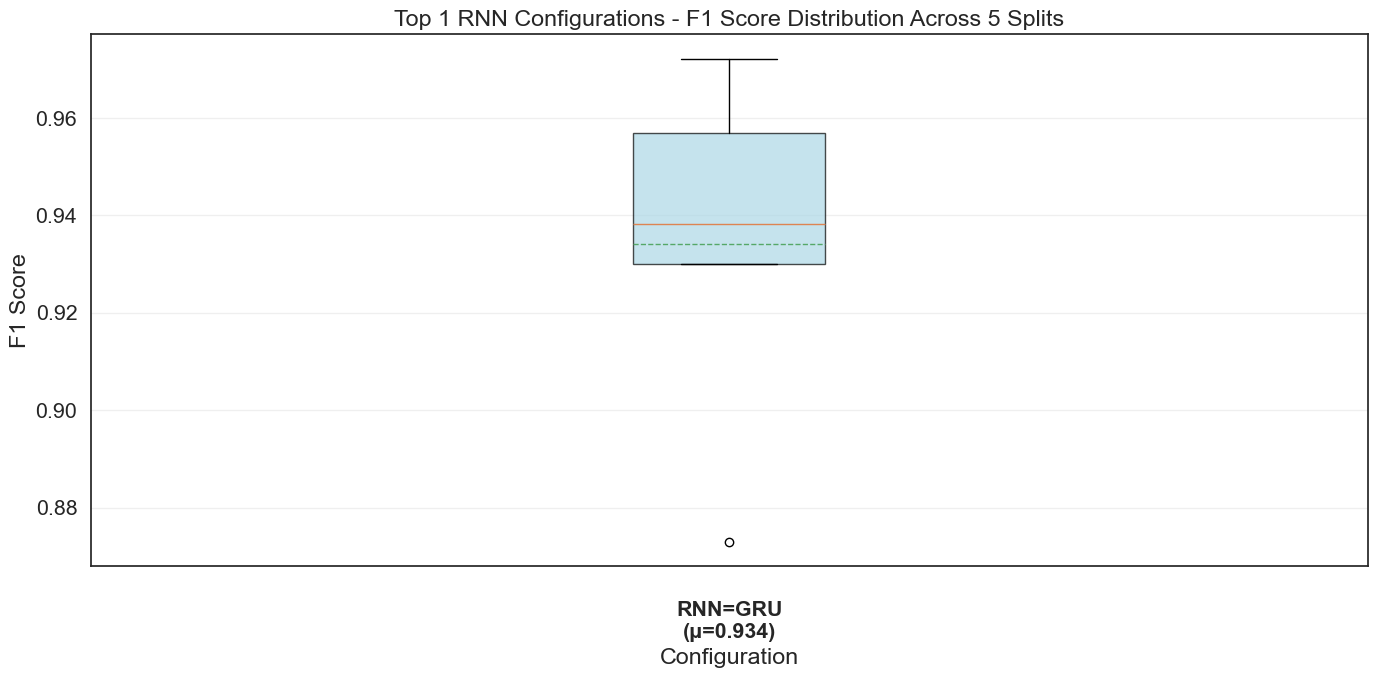

In [ ]:
# Visualise results
plot_top_configurations_rnn(results, k_splits=K, top_n=5)

In [ ]:
final_best_params = {**fixed_params, **best_config}
best_config_str = "_".join([f"{k}_{v}" for k, v in best_config.items()])
#best_config_str = "l2_lambda_0.001"

X_test = pd.read_csv("..\\dataset\\Pirate\\pirate_pain_test.csv")

m = {"two": 2, "one": 1, "zero": 0}

X_test = pd.DataFrame(X_test.drop(["sample_index", "joint_30"], axis=1))
X_test[["n_legs", "n_hands", "n_eyes"]] = X_test[["n_legs", "n_hands", "n_eyes"]].map(lambda x: 1 if x == "two" else 0)

M = int(X_test.shape[0] / 160)

X_test = X_test.to_numpy().reshape(M, T, C).transpose(0, 2, 1)     # X

for n in range(X_test.shape[0]):
    for c in range(8, C):
        X_test[n][c] = (X_test[n][c] - min_val[c - 8]) / (max_val[c - 8] - min_val[c - 8] + 1e-8)

window = final_best_params["window_size"]
stride = final_best_params["stride"]

X_test = X_test.transpose(0, 2, 1)
X_test, _ = build_sequences(X_test, np.zeros(shape=(X_test.shape[0])), window, stride)
shape = X_test.shape
X_test = TensorDataset(torch.from_numpy(X_test).float())

test_loader = make_loader(X_test, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

all_splits_preds = []
for split in range(K):
    model = RecurrentClassifier(
        input_size=shape[2], # num_features (3)
        hidden_size=final_best_params['hidden_size'],
        num_layers=final_best_params['hidden_layers'],
        num_classes=num_classes, # num_classes (6)
        dropout_rate=final_best_params['dropout_rate'],
        bidirectional=final_best_params['bidirectional'],
        rnn_type=final_best_params['rnn_type']
    ).to(device)

    model_path = f"models/{best_config_str}/split_{split}_model.pt"

    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
    except FileNotFoundError:
        print(f"  ERROR: Model file not found at {model_path}")
        print(f"  Skipping split {split+1}.")
        continue

    model.eval() # Set model to evaluation mode

    all_window_preds = []
    with torch.no_grad(): # Disable gradient computation for inference
        for (xb,) in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_window_preds.extend(preds)

    windows_per_signal = (160 - window) // stride + 1   # 29
    num_signals = len(all_window_preds) // windows_per_signal  # 1324

    all_window_preds = np.array(all_window_preds)
    window_groups = all_window_preds.reshape(num_signals, windows_per_signal)

    final_preds = []
    for row in window_groups:
        vals, counts = np.unique(row, return_counts=True)
        final_preds.append(vals[np.argmax(counts)])

    final_preds = np.array(final_preds)
    
    all_splits_preds.append(final_preds)

all_splits_preds = np.stack(all_splits_preds)

final_ensemble = []
for i in range(all_splits_preds.shape[1]):  # for each of the 1324 samples
    votes = all_splits_preds[:, i]          # predictions from each of the K models
    vals, counts = np.unique(votes, return_counts=True)
    final_ensemble.append(vals[np.argmax(counts)])

final_ensemble = np.array(final_ensemble)   # shape = (1324,)

In [ ]:
with open("submission_attention_2.csv", "w") as f:
    f.write("sample_index,label\n")
    
    m = {0: "no_pain", 1: "low_pain", 2: "high_pain"}

    for i in range(final_ensemble.shape[0]):
        f.write(f"{i:03d},{m[final_ensemble[i]]}\n")